# Asymmetry Test (Confidence Sweep Only)

This notebook keeps only the confidence-threshold analysis:
- Mine rules once at the lowest confidence threshold
- Progressively filter for higher thresholds (no re-mining)
- Compare operators with 3 plots:
  - Mean confidence asymmetry
  - Mean support asymmetry
  - Mean bidirectional pairs retained (%)


In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict

import warnings
warnings.filterwarnings(
    'ignore',
    message=r'.*backend2gui is deprecated since IPython 8\.24.*',
    category=DeprecationWarning,
    module=r'IPython\.core\.pylabtools',
)


import FIRM.base.operators.implications as implications
import FIRM.base.operators.tnorms as tnorms
import FIRM.base.fuzzy_data as fuzzy_data
from FIRM.methods.AARFI import AARFI_F
from mlxtend.frequent_patterns import apriori, association_rules

# Operators
p_ss = -10.0
p_ip = 0.01

impl_operators = [
    implications.ImplicationsExamples.get_fuzzy_implication(implications.ImplicationsExamples.IGNORE),
    implications.ImplicationsExamples.get_fuzzy_implication(implications.ImplicationsExamples.LUKASIEWICZ),
    lambda x, y: implications.ImplicationsExamples.get_fuzzy_implication(implications.ImplicationsExamples.KSS)(x, y, float(p_ss)),
    lambda x, y: 1 - x + x * np.power(y, p_ip),
]

tnorms_operators = [
    tnorms.TnormsExamples.get_tnorm(tnorms.TnormsExamples.PRODUCT),
    tnorms.TnormsExamples.get_tnorm(tnorms.TnormsExamples.LUKASIEWICZ),
    lambda x, y: tnorms.TnormsExamples.get_tnorm(tnorms.TnormsExamples.SCHWEIZER_SKLAR)(x, y, float(p_ss)),
    lambda x, y: np.maximum(x + y - 1, 0),
]

def F2_ss_kss(x, y, lam=p_ss):
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    x, y = np.broadcast_arrays(x, y)
    out = np.zeros_like(x, dtype=np.float64)

    m = (x > 0.0) & (y > 0.0)
    if np.any(m):
        xp = x[m]
        yp = y[m]
        with np.errstate(over='ignore', divide='ignore', invalid='ignore'):
            yp_l = np.power(yp, lam)
            cond = np.log(xp) <= (yp_l - 1.0) / lam
            inner = np.power(xp, lam) + yp_l - 1.0 - lam * np.log(xp)
            val = np.power(np.maximum(inner, 0.0), 1.0 / lam)
        out[m] = np.where(cond, xp, val)

    return out

F_operators = [
    lambda x, y: x * y,
    lambda x, y: np.minimum(x, y),
    lambda x, y: F2_ss_kss(x, y, float(p_ss)),
    lambda x, y: x * np.power(y, p_ip),
]

operator_labels = ["TP", "TM", "(TSS?,ISS?)", "(TLK,Ip)"]
crisp_label = "Crisp"

datasets = ['iris.csv', 'wdbc.csv', 'vehicle.csv', 'abalone.csv', 'magic.csv']


In [6]:
def process_df(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for col in out.columns:
        s = out[col]

        if pd.api.types.is_integer_dtype(s):
            out[col] = s.astype('float64')
            continue

        is_cat_like = (
            pd.api.types.is_object_dtype(s)
            or isinstance(s.dtype, pd.CategoricalDtype)
            or pd.api.types.is_string_dtype(s)
        )
        if is_cat_like:
            n_unique = s.nunique(dropna=True)
            if n_unique > 10:
                top10 = s.value_counts(dropna=True).index[:10]
                out[col] = s.where(s.isna() | s.isin(top10), 'Unknown').astype('object')
            else:
                out[col] = s.astype('object')

    return out


def _tokens_from_group(group):
    if group is None:
        return []
    if isinstance(group, (set, frozenset, list, tuple)):
        return [str(x).strip() for x in group if str(x).strip()]
    if pd.isna(group):
        return []

    s = str(group).strip()
    if not s:
        return []
    if s.startswith('(') and s.endswith(')'):
        s = s[1:-1].strip()
    return [t.strip() for t in s.split(',')] if ',' in s else [s]


def _attach_tokens_for_pruning(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df.copy()
    out = df.copy()
    out['ant_tokens'] = out['antecedents'].apply(_tokens_from_group)
    out['con_token'] = out['consequents'].apply(lambda c: (_tokens_from_group(c)[0] if _tokens_from_group(c) else ''))
    return out


def prune_redundant_df(df: pd.DataFrame, epsilon: float) -> pd.DataFrame:
    if df.empty:
        return df

    groups = []
    for _, group in df.groupby('con_token', sort=False):
        group_sorted = group.sort_values('n_antecedents', kind='mergesort')
        kept_idx = []
        kept_ants = []
        kept_conf = []

        for idx, row in group_sorted.iterrows():
            A1 = set(row['ant_tokens'])
            c1 = float(row['confidence'])
            redundant = False

            for A2, c2 in zip(kept_ants, kept_conf):
                if A2.issubset(A1) and abs(c1 - c2) < epsilon:
                    redundant = True
                    break

            if not redundant:
                kept_idx.append(idx)
                kept_ants.append(A1)
                kept_conf.append(c1)

        groups.append(group_sorted.loc[kept_idx])

    return pd.concat(groups, ignore_index=True) if groups else df.iloc[0:0]


def _norm_item(item):
    if isinstance(item, np.ndarray):
        item = item.tolist()
    if isinstance(item, (list, tuple)):
        return tuple(item)
    return (item,)


def _canon_group_fuzzy(group_like):
    if isinstance(group_like, np.ndarray):
        group_like = group_like.tolist()

    if isinstance(group_like, (list, tuple)):
        if len(group_like) == 2 and not isinstance(group_like[0], (list, tuple, np.ndarray)):
            items = [_norm_item(group_like)]
        else:
            items = [_norm_item(x) for x in group_like]
    else:
        items = [_norm_item(group_like)]

    return tuple(sorted(items, key=repr))


def _canon_rule_from_lrule(lr):
    if lr is None:
        return None
    if isinstance(lr, np.ndarray):
        lr = lr.tolist()
    if not isinstance(lr, (list, tuple)) or len(lr) < 2:
        return None

    ant = _canon_group_fuzzy(lr[:-1])
    con = _canon_group_fuzzy(lr[-1])
    return ant, con


def _canon_group_tokens(group):
    return tuple(sorted(_tokens_from_group(group)))


def _asym_value(x: float, y: float, eps: float = 1e-12) -> float:
    denom = abs(x + y)
    if denom <= eps:
        return np.nan
    return abs(x - y) / (denom + eps)


def _summarize_directed_scores(directed_scores: dict):
    conf_asym = []
    supp_asym = []
    seen = set()
    bidirectional_pairs = 0

    for (a, b), vals_ab in directed_scores.items():
        pair_key = tuple(sorted((a, b), key=repr))
        if pair_key in seen:
            continue

        vals_ba = directed_scores.get((b, a))
        if vals_ba is None:
            seen.add(pair_key)
            continue

        conf_ab = float(np.mean([x[0] for x in vals_ab]))
        conf_ba = float(np.mean([x[0] for x in vals_ba]))
        supp_ab = float(np.mean([x[1] for x in vals_ab]))
        supp_ba = float(np.mean([x[1] for x in vals_ba]))

        d_conf = _asym_value(conf_ab, conf_ba)
        d_supp = _asym_value(supp_ab, supp_ba)

        if np.isfinite(d_conf):
            conf_asym.append(d_conf)
        if np.isfinite(d_supp):
            supp_asym.append(d_supp)

        bidirectional_pairs += 1
        seen.add(pair_key)

    total_undirected_pairs = len({tuple(sorted((a, b), key=repr)) for (a, b) in directed_scores.keys()})
    bidirectional_rate = (float(bidirectional_pairs / total_undirected_pairs) if total_undirected_pairs else np.nan)

    return {
        'TotalUndirectedPairs': int(total_undirected_pairs),
        'BidirectionalPairs': int(bidirectional_pairs),
        'BidirectionalRatePct': (100.0 * bidirectional_rate) if np.isfinite(bidirectional_rate) else np.nan,
        'MeanAsymConf': float(np.mean(conf_asym)) if conf_asym else np.nan,
        'MeanAsymSupp': float(np.mean(supp_asym)) if supp_asym else np.nan,
    }


def summarize_fuzzy_singleton(measures_df: pd.DataFrame):
    directed = defaultdict(list)

    if measures_df is None or measures_df.empty:
        return {
            'TotalUndirectedPairs': 0,
            'BidirectionalPairs': 0,
            'BidirectionalRatePct': np.nan,
            'MeanAsymConf': np.nan,
            'MeanAsymSupp': np.nan,
        }

    for _, row in measures_df.iterrows():
        rule = _canon_rule_from_lrule(row.get('lrule'))
        if rule is None:
            continue

        a, b = rule
        if not a or not b or len(a) != 1 or len(b) != 1 or a == b:
            continue

        conf = float(row.get('confidence', np.nan))
        supp = float(row.get('support', np.nan))
        if not np.isfinite(conf) or not np.isfinite(supp):
            continue

        directed[(a, b)].append((conf, supp))

    return _summarize_directed_scores(directed)


def summarize_crisp_singleton(df_rules: pd.DataFrame):
    directed = defaultdict(list)

    if df_rules is None or df_rules.empty:
        return {
            'TotalUndirectedPairs': 0,
            'BidirectionalPairs': 0,
            'BidirectionalRatePct': np.nan,
            'MeanAsymConf': np.nan,
            'MeanAsymSupp': np.nan,
        }

    for _, row in df_rules.iterrows():
        a = _canon_group_tokens(row.get('antecedents'))
        b = _canon_group_tokens(row.get('consequents'))

        if not a or not b or len(a) != 1 or len(b) != 1 or a == b:
            continue

        conf = float(row.get('confidence', np.nan))
        supp = float(row.get('support', np.nan))
        if not np.isfinite(conf) or not np.isfinite(supp):
            continue

        directed[(a, b)].append((conf, supp))

    return _summarize_directed_scores(directed)


In [7]:
def run_conf_threshold_sweep_once(
    datasets,
    conf_grid,
    min_cov=0.2,
    min_supp=0.2,
    max_feat=1,
    prune_epsilon=0.05,
    verbose=False,
):
    if int(max_feat) != 1:
        raise ValueError('Use max_feat=1 for reversible singleton pairs (A->B vs B->A).')

    conf_grid = sorted({float(c) for c in conf_grid})
    if not conf_grid:
        raise ValueError('conf_grid must contain at least one value.')
    conf_base = conf_grid[0]

    prepared = {}
    for name_dataset in datasets:
        dataset = process_df(pd.read_csv('../assets/' + name_dataset, sep=','))
        int_cols = dataset.select_dtypes(include=['int']).columns
        if len(int_cols):
            dataset[int_cols] = dataset[int_cols].astype(float)
        fdata = fuzzy_data.FuzzyDataQuantiles(name_dataset, dataset, 3, ['L', 'M', 'H'])
        prepared[name_dataset] = (dataset, fdata)

    rows = []

    print(
        f'Conf sweep (single mining) -> min_cov={min_cov}, min_supp={min_supp}, '
        f'conf_base={conf_base}, max_feat={max_feat}, prune_epsilon={prune_epsilon}, '
        f'conf_grid={conf_grid}'
    )

    # Fuzzy operators: mine once at conf_base, then progressively filter by confidence
    for op_idx, (I, T, F) in enumerate(zip(impl_operators, tnorms_operators, F_operators)):
        for name_dataset in datasets:
            dataset, fdata = prepared[name_dataset]

            _rules, measures_base = AARFI_F(
                dataset,
                fdata,
                F=F,
                T=T,
                I=I,
                min_cov=min_cov,
                min_supp=min_supp,
                min_conf=conf_base,
                prune_epsilon=prune_epsilon,
                max_feat=max_feat,
                verbose=verbose,
            )

            if measures_base is None or measures_base.empty:
                selected = pd.DataFrame(columns=['lrule', 'support', 'confidence'])
            else:
                selected = measures_base[
                    (measures_base['support'] >= min_supp) & (measures_base['confidence'] >= conf_base)
                ].sort_values('confidence', ascending=True).reset_index(drop=True)

            for conf in conf_grid:
                if not selected.empty:
                    selected = selected[selected['confidence'] >= conf].reset_index(drop=True)

                summary = summarize_fuzzy_singleton(selected)
                rows.append({
                    'OperatorLabel': operator_labels[op_idx],
                    'Dataset': name_dataset,
                    'MinConf': float(conf),
                    'NumRules': int(len(selected)),
                    'TotalUndirectedPairs': summary['TotalUndirectedPairs'],
                    'BidirectionalPairs': summary['BidirectionalPairs'],
                    'BidirectionalRatePct': summary['BidirectionalRatePct'],
                    'MeanAsymConf': summary['MeanAsymConf'],
                    'MeanAsymSupp': summary['MeanAsymSupp'],
                })

    # Crisp baseline: mine once at conf_base, then progressively filter by confidence
    for name_dataset in datasets:
        dataset, fdata = prepared[name_dataset]

        data = dataset.copy()
        for i in range(len(fdata.fv_list)):
            data[dataset.columns[i]] = dataset[dataset.columns[i]].map(
                lambda x: fdata.fv_list[i].eval_max_fuzzy_set(x)
            )

        df_encoded = pd.get_dummies(data, columns=data.columns)
        df_freq = apriori(
            df_encoded,
            min_support=min_supp,
            use_colnames=True,
            verbose=0,
            max_len=max_feat + 1,
            low_memory=True,
        )

        if df_freq.empty:
            selected = pd.DataFrame(columns=['antecedents', 'consequents', 'support', 'confidence'])
        else:
            df_ar = association_rules(df_freq, metric='confidence', min_threshold=conf_base)
            selected = df_ar[
                (df_ar['antecedents'].apply(len) <= max_feat)
                & (df_ar['consequents'].apply(len) <= 1)
            ].reset_index(drop=True)

            if not selected.empty:
                selected = selected.assign(n_antecedents=selected['antecedents'].apply(len))
                selected = _attach_tokens_for_pruning(selected)
                selected = prune_redundant_df(selected, prune_epsilon)
                selected = selected[
                    (selected['support'] >= min_supp) & (selected['confidence'] >= conf_base)
                ].sort_values('confidence', ascending=True).reset_index(drop=True)

        for conf in conf_grid:
            if not selected.empty:
                selected = selected[selected['confidence'] >= conf].reset_index(drop=True)

            summary = summarize_crisp_singleton(selected)
            rows.append({
                'OperatorLabel': crisp_label,
                'Dataset': name_dataset,
                'MinConf': float(conf),
                'NumRules': int(len(selected)),
                'TotalUndirectedPairs': summary['TotalUndirectedPairs'],
                'BidirectionalPairs': summary['BidirectionalPairs'],
                'BidirectionalRatePct': summary['BidirectionalRatePct'],
                'MeanAsymConf': summary['MeanAsymConf'],
                'MeanAsymSupp': summary['MeanAsymSupp'],
            })

    return pd.DataFrame(rows)


Conf sweep (single mining) -> min_cov=0.1, min_supp=0.1, conf_base=0.1, max_feat=1, prune_epsilon=0.05, conf_grid=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
Rows in conf_sweep: 225
Confidence levels: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

Mean confidence asymmetry by confidence threshold (avg over datasets):
OperatorLabel        TP        TM  (TSS?,ISS?)  (TLK,Ip)     Crisp
MinConf                                                           
0.1            0.079443  0.083610     0.083379  0.071057  0.080244
0.2            0.078925  0.083168     0.082931  0.071057  0.080094
0.3            0.058477  0.064516     0.064285  0.066984  0.064471
0.4            0.040560  0.042024     0.041830  0.047407  0.044214
0.5            0.032623  0.031811     0.031576  0.035938  0.038851
0.6            0.024998  0.024960     0.024975  0.030213  0.030322
0.7            0.021047  0.020990     0.020899  0.020067  0.023149
0.8            0.014976  0.015073     0.014965  0.015113  0.018937
0.9      

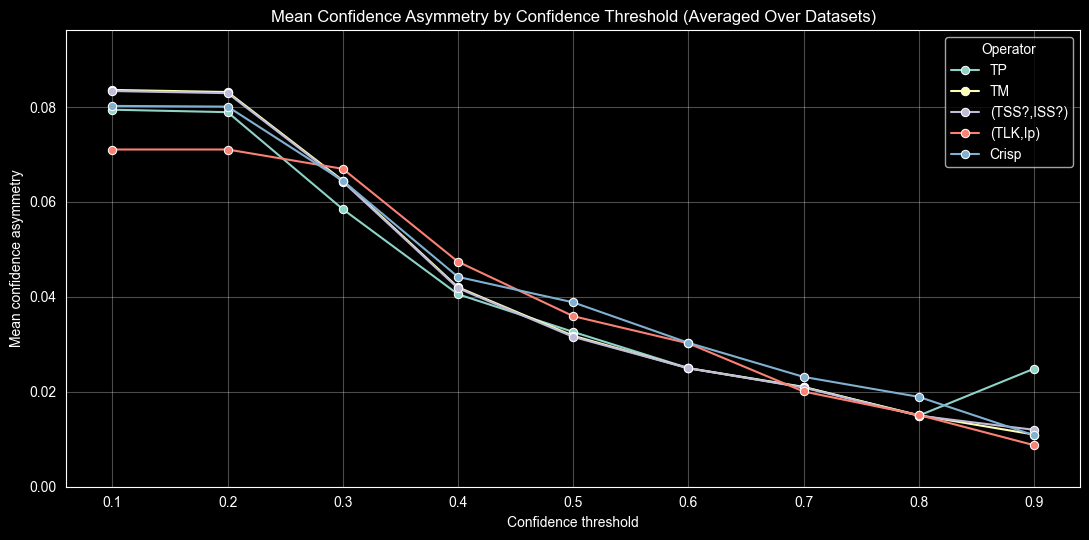

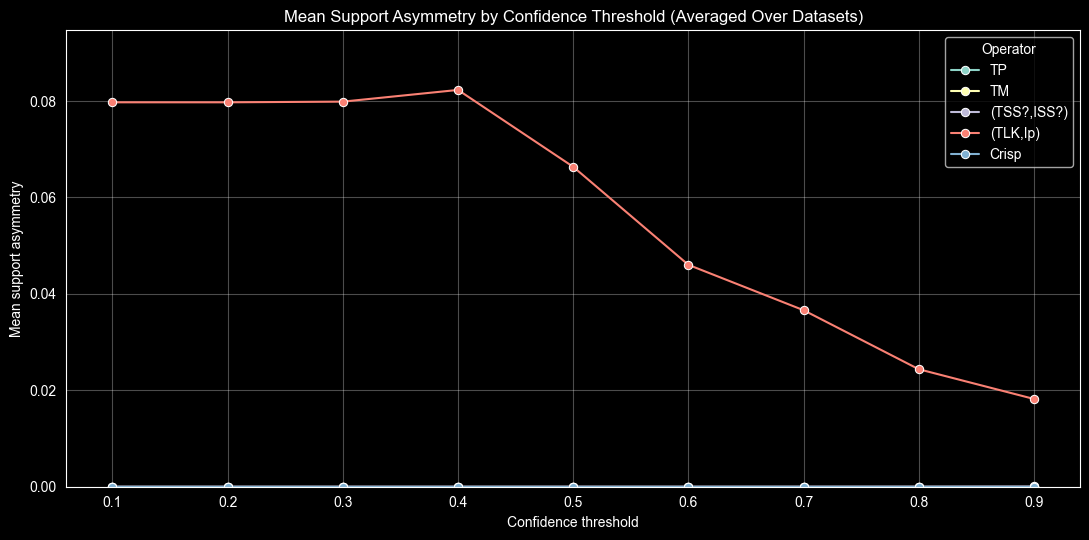

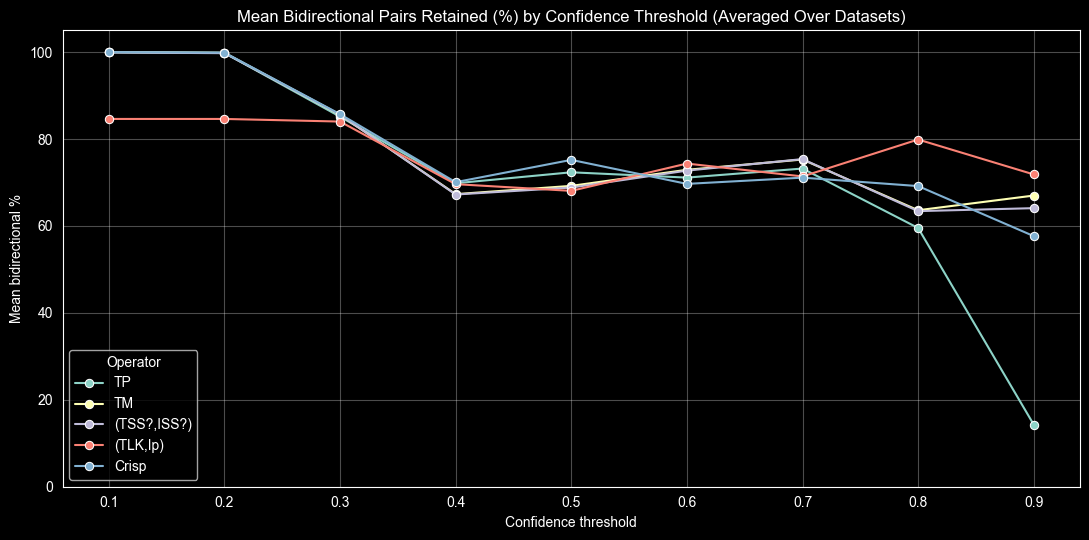

In [8]:
RUN_CFG = {
    'min_cov': 0.1,
    'min_supp': 0.1,
    'max_feat': 1,
    'prune_epsilon': 0.05,
}
CONF_SWEEP_GRID = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

conf_sweep = run_conf_threshold_sweep_once(
    datasets=datasets,
    conf_grid=CONF_SWEEP_GRID,
    **RUN_CFG,
)

print('Rows in conf_sweep:', len(conf_sweep))
print('Confidence levels:', sorted(conf_sweep['MinConf'].unique().tolist()))

# Mean by confidence threshold (averaged over datasets)
mean_by_conf = (
    conf_sweep
    .groupby(['OperatorLabel', 'MinConf'], as_index=False)
    .agg({
        'MeanAsymConf': 'mean',
        'MeanAsymSupp': 'mean',
        'BidirectionalRatePct': 'mean',
    })
)

op_order = operator_labels + [crisp_label]
mean_by_conf['OperatorLabel'] = pd.Categorical(mean_by_conf['OperatorLabel'], categories=op_order, ordered=True)
mean_by_conf = mean_by_conf.sort_values(['MinConf', 'OperatorLabel'])

print()
print('Mean confidence asymmetry by confidence threshold (avg over datasets):')
print(mean_by_conf.pivot(index='MinConf', columns='OperatorLabel', values='MeanAsymConf').reindex(columns=op_order).to_string())

print()
print('Mean support asymmetry by confidence threshold (avg over datasets):')
print(mean_by_conf.pivot(index='MinConf', columns='OperatorLabel', values='MeanAsymSupp').reindex(columns=op_order).to_string())

print()
print('Mean bidirectional % by confidence threshold (avg over datasets):')
print(mean_by_conf.pivot(index='MinConf', columns='OperatorLabel', values='BidirectionalRatePct').reindex(columns=op_order).to_string())

conf_ymax = max(0.05, float(mean_by_conf['MeanAsymConf'].max()) * 1.15 if len(mean_by_conf) else 0.05)
supp_ymax = max(0.05, float(mean_by_conf['MeanAsymSupp'].max()) * 1.15 if len(mean_by_conf) else 0.05)

# Plot 1: confidence asymmetry
plt.figure(figsize=(11, 5.5))
ax = sns.lineplot(
    data=mean_by_conf,
    x='MinConf',
    y='MeanAsymConf',
    hue='OperatorLabel',
    hue_order=op_order,
    marker='o',
)
ax.set_title('Mean Confidence Asymmetry by Confidence Threshold (Averaged Over Datasets)')
ax.set_xlabel('Confidence threshold')
ax.set_ylabel('Mean confidence asymmetry')
ax.set_ylim(0, conf_ymax)
ax.grid(True, alpha=0.3)
ax.legend(title='Operator')
plt.tight_layout()
plt.show()

# Plot 2: support asymmetry
plt.figure(figsize=(11, 5.5))
ax = sns.lineplot(
    data=mean_by_conf,
    x='MinConf',
    y='MeanAsymSupp',
    hue='OperatorLabel',
    hue_order=op_order,
    marker='o',
)
ax.set_title('Mean Support Asymmetry by Confidence Threshold (Averaged Over Datasets)')
ax.set_xlabel('Confidence threshold')
ax.set_ylabel('Mean support asymmetry')
ax.set_ylim(0, supp_ymax)
ax.grid(True, alpha=0.3)
ax.legend(title='Operator')
plt.tight_layout()
plt.show()

# Plot 3: bidirectional percentage
plt.figure(figsize=(11, 5.5))
ax = sns.lineplot(
    data=mean_by_conf,
    x='MinConf',
    y='BidirectionalRatePct',
    hue='OperatorLabel',
    hue_order=op_order,
    marker='o',
)
ax.set_title('Mean Bidirectional Pairs Retained (%) by Confidence Threshold (Averaged Over Datasets)')
ax.set_xlabel('Confidence threshold')
ax.set_ylabel('Mean bidirectional %')
ax.set_ylim(0, 105)
ax.grid(True, alpha=0.3)
ax.legend(title='Operator')
plt.tight_layout()
plt.show()
